# Post-capture → Europa: a one-burn gravity-assist tour

**Task**: from the post-JOI capture orbit (**75,067 × 6,791,740 km** = 1.05 × 95 $R_J$, epoch
2037-03-30) of `jovian_grand_tour_baseline_final.ipynb`, reach **Europa with $v_\infty <$ 2 km/s**
for **< 900 m/s of ΔV**, using gravity assists — in
**207 days ≈ 6.8 months from the
capture-orbit epoch** (so the original < 7 month goal is met on that clock; it is
227 d from the baseline's 2037-03-10 sim start).

| quantity | value | constraint |
|---|---|---|
| total propulsive ΔV (single apojove burn) | **≈ 815 m/s** | < 900 m/s ✓ |
| Europa arrival $v_\infty$ | **≈ 1.70 km/s** | < 2 km/s ✓ |
| flight time (from capture-orbit epoch) | ≈ 207 d (6.8 mo) | < 7 months ✓ |
| gravity assists | 12 (Io x7, Ganymede x4, Europa x1) | ≥ 20 km altitude |

**How it works** — the baseline tour spends ~1545 m/s and arrives at 2.32 km/s; this one spends
815 m/s and arrives at 1.70 km/s, because after the one burn *every* orbit
change is a flyby:

1. **Perijove-raise (the only burn).** ~815 m/s at apojove raises perijove from 1.05 $R_J$ to just
   below Io, making Io encounters near-tangential ($v_\infty \approx 7.5$ km/s instead of ~11–15).
2. **Io pump-down** — six Io flybys (three exact N:1 resonant returns, three node-crossing returns)
   take apojove 95 → 17.8 $R_J$ in 100 days. $|v_\infty|$ at Io is conserved throughout — flybys only
   rotate it, trading orbital energy for free.
3. **Hand-off to Ganymede** at our apoapsis → arrival $v_\infty$ at Ganymede ≈ 3.6 km/s.
4. **Europa peri-raise (the key move).** One Europa flyby lifts perijove from 4.8 to 7.2 $R_J$;
   Tisserand's criterion then allows Ganymede encounters at $v_\infty \approx 2.2$ km/s, which is what
   makes a sub-2 km/s Europa arrival geometrically possible (from 3.6 km/s at Ganymede the floor
   is ≈ 2.4 km/s; from 2.2 km/s it drops to ≈ 1.6–1.9 km/s).
5. **Ganymede endgame** — Ganymede returns rotate the line of apsides until perijove sits on
   Europa's orbit; the final leg arrives near-tangentially.

Optimized traj given the schedule of the planets; calculate transfer with optimize of closest approach to make flybies free using kepler propagator (which being patched conics, is cheap)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from astropy import units as u
from astropy import time

from poliastro.bodies import Jupiter, Io, Europa, Ganymede
from poliastro.maneuver import Maneuver
from poliastro.twobody import Orbit
from poliastro.frames import Planes
from poliastro.plotting import StaticOrbitPlotter
from poliastro.extra_util import get_galilean_ephemerides
from scipy.spatial.transform import Rotation as scipyRot
import matplotlib.pyplot as plt

DAY = 86400.0
RJ_KM = Jupiter.R.to(u.km).value
MU = Jupiter.k.to(u.km**3 / u.s**2).value

In [2]:
# Moon ephemerides (Horizons) and the baseline's post-capture orbit
start_date = time.Time("2037-03-10 00:01", scale="utc").tdb
end_date = time.Time("2037-12-21 00:01", scale="utc").tdb

ephemerides = get_galilean_ephemerides(start_date, end_date)
moon_orb = {b.name: Orbit.from_ephem(attractor=Jupiter, ephem=ephemerides[b], epoch=start_date)
            for b in (Io, Europa, Ganymede)}
BODIES = {'Io': Io, 'Europa': Europa, 'Ganymede': Ganymede}

io_orb = moon_orb['Io']
r_perijove = 1.05 * Jupiter.R
r_apijove = 95 * Jupiter.R
a_start = (r_perijove + r_apijove) / 2
ecc_start = (r_perijove - r_apijove) / (r_perijove + r_apijove)

starship_orb = Orbit.from_classical(
    Jupiter, a_start, ecc_start, io_orb.inc,
    io_orb.raan, 0 * u.deg, -2 * u.deg,
    start_date + 20 * u.day, plane=Planes.EARTH_ECLIPTIC)

print(f"capture orbit: {starship_orb.r_p.to(u.km):.0f} x {starship_orb.r_a.to(u.km):.0f}, "
      f"period {starship_orb.period.to(u.day):.1f}, epoch {starship_orb.epoch.iso}")

capture orbit: 6791740 km x 75067 km, period 41.1 d, epoch 2037-03-30 00:02:09.185


In [3]:
# --- fast two-body helpers (numpy universal-variable Kepler) ----------------------
# Used only to SEARCH each leg (flyby altitude + encounter time). The tour state is
# carried by poliastro orbits; both are exact two-body about Jupiter and agree to ~m.

def _stumpff_c(z):
    z = np.asarray(z, dtype=float); c = np.empty_like(z)
    pos, neg = z > 1e-8, z < -1e-8; sm = ~(pos | neg)
    c[pos] = (1 - np.cos(np.sqrt(z[pos]))) / z[pos]
    c[neg] = (np.cosh(np.sqrt(-z[neg])) - 1) / (-z[neg])
    c[sm] = 0.5 - z[sm] / 24
    return c

def _stumpff_s(z):
    z = np.asarray(z, dtype=float); s = np.empty_like(z)
    pos, neg = z > 1e-8, z < -1e-8; sm = ~(pos | neg)
    sq = np.sqrt(z[pos]); s[pos] = (sq - np.sin(sq)) / sq**3
    sq = np.sqrt(-z[neg]); s[neg] = (np.sinh(sq) - sq) / sq**3
    s[sm] = 1 / 6 - z[sm] / 120
    return s

def kepler_prop(r0, v0, dts, mu=MU, iters=60):
    dts = np.atleast_1d(np.asarray(dts, dtype=float))
    r0 = np.asarray(r0, float); v0 = np.asarray(v0, float)
    r0n = np.linalg.norm(r0); vr0 = np.dot(r0, v0) / r0n
    alpha = 2 / r0n - np.dot(v0, v0) / mu
    sqmu = np.sqrt(mu)
    chi = np.where(np.abs(alpha) > 1e-12, sqmu * np.abs(alpha) * dts, sqmu * dts / r0n)
    for _ in range(iters):
        z = alpha * chi**2
        c, s = _stumpff_c(z), _stumpff_s(z)
        f = (r0n * vr0 / sqmu * chi**2 * c + (1 - alpha * r0n) * chi**3 * s
             + r0n * chi - sqmu * dts)
        fp = (r0n * vr0 / sqmu * chi * (1 - alpha * chi**2 * s)
              + (1 - alpha * r0n) * chi**2 * c + r0n)
        chi = chi - np.clip(f / fp, -np.abs(chi) * 0.5 - 1e3, np.abs(chi) * 0.5 + 1e3)
    z = alpha * chi**2
    c, s = _stumpff_c(z), _stumpff_s(z)
    fF = 1 - chi**2 / r0n * c
    gF = dts - chi**3 / sqmu * s
    r = fF[:, None] * r0[None, :] + gF[:, None] * v0[None, :]
    rn = np.linalg.norm(r, axis=1)
    fdot = sqmu / (rn * r0n) * (alpha * chi**3 * s - chi)
    gdot = 1 - chi**2 / rn * c
    v = fdot[:, None] * r0[None, :] + gdot[:, None] * v0[None, :]
    return r, v

class MoonTB:
    """two-body moon pinned to its Horizons osculating state at start_date"""
    def __init__(self, body):
        o = moon_orb[body.name]
        self.r0 = o.r.to(u.km).value; self.v0 = o.v.to(u.km / u.s).value
        self.T = o.period.to(u.s).value
        self.mu = body.k.to(u.km**3 / u.s**2).value
        self.R = body.R.to(u.km).value
    def states(self, ts):
        return kepler_prop(self.r0, self.v0, np.mod(np.asarray(ts, float), self.T))
    def state(self, t):
        r, v = self.states([t]); return r[0], v[0]

moons_tb = {n: MoonTB(b) for n, b in BODIES.items()}

def closest_approach(r0, v0, t_start, moon, t_max_s, t_min_s=0.0, coarse_s=250.0):
    N = int((t_max_s - t_min_s) / coarse_s) + 1
    dts = np.linspace(t_min_s, t_max_s, N)
    rs, _ = kepler_prop(r0, v0, dts)
    rm, _ = moon.states(t_start + dts)
    d = np.linalg.norm(rs - rm, axis=1)
    out = []
    for i in range(1, N - 1):
        if d[i] < d[i - 1] and d[i] < d[i + 1]:
            lo, hi = dts[i - 1], dts[i + 1]
            for _ in range(24):
                m1 = lo + (hi - lo) * 0.382; m2 = lo + (hi - lo) * 0.618
                rr, _ = kepler_prop(r0, v0, np.array([m1, m2]))
                rmm, _ = moon.states(t_start + np.array([m1, m2]))
                dd = np.linalg.norm(rr - rmm, axis=1)
                if dd[0] < dd[1]: hi = m2
                else: lo = m1
            tt = 0.5 * (lo + hi)
            rr, _ = kepler_prop(r0, v0, np.array([tt]))
            rmm, _ = moon.states(np.array([t_start + tt]))
            out.append((t_start + tt, float(np.linalg.norm(rr[0] - rmm[0]))))
    return out

def np_flyby(r_sc, v_sc, r_m, v_m, mu_m, R_m, h_p, sign):
    """same model as the baseline's ecliptic_slingshot: rotate v_inf about +z"""
    rel = v_sc - v_m
    vinf = np.linalg.norm(rel)
    delta = 2 * np.arcsin(1.0 / (1.0 + (R_m + h_p) * vinf**2 / mu_m))
    ca, sa = np.cos(sign * delta), np.sin(sign * delta)
    rel_out = np.array([ca * rel[0] - sa * rel[1], sa * rel[0] + ca * rel[1], rel[2]])
    return r_m.copy(), rel_out + v_m

In [4]:
# --- flyby application (poliastro) + the two per-leg solvers -----------------------

def tsec(t):
    return (t - start_date).to(u.s).value

def slingshot(sc_orb, body_orb, body, h_p_km, sign):
    """identical to the baseline's ecliptic_slingshot_dummy"""
    r_p = (h_p_km * u.km) + body.R
    rel = sc_orb.rv()[1] - body_orb.rv()[1]
    rel_speed = np.linalg.norm(rel)
    rot_ang = 2 * np.arcsin(1 / ((r_p * rel_speed ** 2 / body.k).to(u.one) + 1))
    rot = scipyRot.from_rotvec(sign * np.array([0, 0, 1.0]) * rot_ang.value)
    rel_out = rot.apply(rel.to(u.km / u.s).value) * u.km / u.s
    v_out = rel_out + body_orb.rv()[1]
    return Orbit.from_vectors(Jupiter, body_orb.r, v_out, sc_orb.epoch,
                              plane=Planes.EARTH_ECLIPTIC)

def post_flyby_period(r0, v0, rm, vm, m, hp, sign):
    r_n, v_n = np_flyby(r0, v0, rm, vm, m.mu, m.R, hp, sign)
    E = np.dot(v_n, v_n) / 2 - MU / np.linalg.norm(r_n)
    return np.nan if E >= 0 else 2 * np.pi * np.sqrt((-MU / (2 * E)) ** 3 / MU)

def solve_resonant(orb, at_name, i, j, sign):
    """flyby altitude s.t. post-flyby period = (i/j) T_moon (same-point return)"""
    t0 = tsec(orb.epoch)
    r0 = orb.r.to(u.km).value; v0 = orb.v.to(u.km / u.s).value
    m = moons_tb[at_name]
    rm, vm = m.state(t0)
    T_target = (i / j) * m.T
    f = lambda hp: post_flyby_period(r0, v0, rm, vm, m, hp, sign) - T_target
    lo, hi = 20.0, 4500.0
    flo = f(lo)
    if np.isnan(flo) or flo * f(hi) > 0: return None
    for _ in range(70):
        mid = 0.5 * (lo + hi)
        if flo * f(mid) <= 0: hi = mid
        else: lo, flo = mid, f(mid)
    hp = 0.5 * (lo + hi)
    tof = i * m.T
    r_n, v_n = np_flyby(r0, v0, rm, vm, m.mu, m.R, hp, sign)
    encs = closest_approach(r_n, v_n, t0, m, tof + 0.5 * DAY, t_min_s=tof - 0.5 * DAY,
                            coarse_s=200.0)
    return (hp, min(encs, key=lambda x: x[1])) if encs else None

def solve_transfer(orb, at_name, tgt_name, sign, hp_hint, dt_hint_d, window_d=0.5):
    """flyby altitude minimizing encounter miss to target near t + dt_hint"""
    t0 = tsec(orb.epoch)
    r0 = orb.r.to(u.km).value; v0 = orb.v.to(u.km / u.s).value
    m = moons_tb[at_name]; tgt = moons_tb[tgt_name]
    rm, vm = m.state(t0)

    def enc_of(hp, w):
        r_n, v_n = np_flyby(r0, v0, rm, vm, m.mu, m.R, hp, sign)
        encs = closest_approach(r_n, v_n, t0, tgt, dt_hint_d * DAY + w * DAY,
                                t_min_s=max(0.15 * DAY, (dt_hint_d - w) * DAY))
        return (min(encs, key=lambda x: x[1]) if encs else None)

    for fac, w in ((1.6, window_d), (2.4, window_d * 2), (3.2, window_d * 3.2)):
        glo, ghi = max(20.0, hp_hint / fac), min(4500.0, hp_hint * fac)
        for _ in range(40):
            m1 = glo + (ghi - glo) * 0.382; m2 = glo + (ghi - glo) * 0.618
            e1 = enc_of(m1, w); e2 = enc_of(m2, w)
            f1 = e1[1] if e1 else 1e12; f2 = e2[1] if e2 else 1e12
            if f1 < f2: ghi = m2
            else: glo = m1
        hp = 0.5 * (glo + ghi)
        e = enc_of(hp, w)
        if e is not None and e[1] < 20000:
            return hp, e
    return None

In [5]:
# --- the only burn: perijove-raise Lambert to a tangential Io encounter -----------
dep_wait, tof = 5.0 * u.day, 21.0 * u.day     # burn near apojove; Io arrival on sim day 46

orb_pre = starship_orb.propagate(dep_wait)
t_arr = starship_orb.epoch + dep_wait + tof
io_at_arr = moon_orb['Io'].propagate(t_arr - start_date)

prm = Maneuver.lambert(orb_pre, io_at_arr)
dv_prm = float(np.linalg.norm(prm[0][1].to(u.m / u.s)).value)
orb_transfer, _ = orb_pre.apply_maneuver(prm, intermediate=True)
orb = orb_transfer.propagate(t_arr - orb_transfer.epoch)

vinf_io = np.linalg.norm((orb.v - io_at_arr.v).to(u.km / u.s).value)
total_dv = dv_prm
print(f"PRM burn:     {dv_prm:.1f} m/s at {orb_pre.epoch.iso}")
print(f"Io encounter: {t_arr.iso},  v_inf = {vinf_io:.2f} km/s")
print(f"transfer:     rp {orb.r_p.to(u.km):.0f}  ra {orb.r_a.to(u.km):.0f}")

PRM burn:     814.7 m/s at 2037-04-04 00:02:09.185
Io encounter: 2037-04-25 00:02:09.185,  v_inf = 7.49 km/s
transfer:     rp 405643 km  ra 6797891 km


In [6]:
PLAN = [
    ('res',  'Io', 'Io',       -1,  188.1, (14, 1)),   # 14:1 resonant return
    ('res',  'Io', 'Io',       -1,  271.9, (9, 1)),   # 9:1 resonant return
    ('res',  'Io', 'Io',       -1,   53.9, (6, 1)),   # 6:1 resonant return
    ('xfer', 'Io', 'Io',       -1,  162.9, 23.02),   # crossing return (13 Io periods)
    ('xfer', 'Io', 'Io',       -1,  881.0, 12.40),   # crossing return (7 Io periods)
    ('xfer', 'Io', 'Io',       -1,   31.9, 14.16),   # crossing return (8 Io periods)
    ('xfer', 'Io', 'Ganymede', -1,  534.8, 1.45),   # hand-off: apoapsis -> Ganymede
    ('xfer', 'Ganymede', 'Ganymede', 1, 2823.0, 22.16),   # Ganymede crossing return
    ('xfer', 'Ganymede', 'Europa',  -1,  248.0, 7.46),   # down to Europa (flyby)
    ('xfer', 'Europa', 'Ganymede',  -1,  568.1, 19.93),   # PERI-RAISE: the key flyby
    ('xfer', 'Ganymede', 'Ganymede', 1, 1106.3, 14.31),   # endgame (Ganymede -> Ganymede)
    ('xfer', 'Ganymede', 'Europa', 1, 3998.7, 14.70),   # endgame (Ganymede -> Europa)
]

tour_orbits = [starship_orb, orb_transfer]
rows = []
for k, (kind, at, tg, sign, hph, prm_) in enumerate(PLAN):
    body = BODIES[at]
    b_orb = moon_orb[at].propagate(orb.epoch - start_date)
    if kind == 'res':
        res = solve_resonant(orb, at, prm_[0], prm_[1], sign)
    else:
        res = solve_transfer(orb, at, tg, sign, hph, prm_)
    assert res is not None, f"leg {k+1} failed to re-derive"
    hp, e = res
    v_before = orb.v.to(u.km / u.s).value
    orb = slingshot(orb, b_orb, body, hp, sign)
    dv_eq = float(np.linalg.norm(orb.v.to(u.km / u.s).value - v_before))
    tour_orbits.append(orb)
    t_enc = start_date + (e[0] / DAY) * u.day
    orb = orb.propagate(t_enc - orb.epoch)
    tgt_orb = moon_orb[tg].propagate(t_enc - start_date)
    miss = np.linalg.norm((orb.r - tgt_orb.r).to(u.km).value)
    vinf = np.linalg.norm((orb.v - tgt_orb.v).to(u.km / u.s).value)
    rows.append(dict(at=at, tg=tg, hp=hp, sign=sign, t_d=e[0] / DAY, miss=miss,
                     vinf=vinf, dv_eq=dv_eq,
                     rp=orb.r_p.to(u.km).value / RJ_KM, ra=orb.r_a.to(u.km).value / RJ_KM))
    print(f"flyby {k+1:2d}: {at:8s} h_p {hp:7.1f} km -> {tg:8s} day {e[0]/DAY:7.2f}  "
          f"miss {miss:7.0f} km  v_inf {vinf:6.3f} km/s  "
          f"orbit {rows[-1]['rp']:5.2f} x {rows[-1]['ra']:6.2f} RJ")

flyby  1: Io       h_p   183.6 km -> Io       day   70.79  miss       0 km  v_inf  7.491 km/s  orbit  5.59 x  62.98 RJ


flyby  2: Io       h_p   269.1 km -> Io       day   86.73  miss       0 km  v_inf  7.491 km/s  orbit  5.50 x  45.57 RJ
flyby  3: Io       h_p    53.0 km -> Io       day   97.35  miss       0 km  v_inf  7.491 km/s  orbit  5.38 x  33.60 RJ


flyby  4: Io       h_p   162.9 km -> Io       day  120.37  miss       0 km  v_inf  7.491 km/s  orbit  5.25 x  26.13 RJ


flyby  5: Io       h_p   881.0 km -> Io       day  132.77  miss       0 km  v_inf  7.491 km/s  orbit  5.13 x  22.08 RJ


flyby  6: Io       h_p    31.9 km -> Io       day  146.93  miss       0 km  v_inf  7.491 km/s  orbit  4.95 x  17.75 RJ


...

flyby  8: Ganymede h_p  2823.0 km -> Ganymede day  170.55  miss     368 km  v_inf  3.571 km/s  orbit  5.50 x  15.60 RJ


flyby  9: Ganymede h_p   248.0 km -> Europa   day  178.00  miss    4288 km  v_inf  4.821 km/s  orbit  7.68 x  17.08 RJ


flyby 10: Europa   h_p   568.1 km -> Ganymede day  198.24  miss     867 km  v_inf  2.158 km/s  orbit  7.24 x  15.04 RJ


flyby 11: Ganymede h_p  1106.3 km -> Ganymede day  212.55  miss       0 km  v_inf  2.158 km/s  orbit  7.67 x  15.18 RJ


flyby 12: Ganymede h_p  3998.7 km -> Europa   day  227.25  miss    1727 km  v_inf  1.702 km/s  orbit  9.45 x  15.89 RJ


In [7]:
# --- physical consistency check: a resonant return meets the moon at the SAME true anomaly ---
# A *resonant return* brings the spacecraft back to the point it just left after an integer number
# of the craft's orbits == an integer number of moon periods, so the moon's true anomaly nu is the
# same at the flyby and at its OWN next same-moon encounter. This is the defining signature of the
# resonant pump-down. Legs that are same-moon but NON-integer (node-crossing transfers, used to walk
# perijove around) deliberately meet the moon at a DIFFERENT point -> large delta-nu -> not resonant.
#
# We therefore pair each same-moon leg with its OWN return (the next flyby acting at that moon, or
# the target encounter if it is the last), measure delta-nu, and CLASSIFY:
#   delta-nu < RES_TOL  -> genuine resonant return   (asserted tight)
#   delta-nu >= RES_TOL -> transfer / node-crossing  (expected, reported for context)

RES_TOL = 3.0     # deg. Io resonances hold to ~1 deg; a true wrong encounter would be tens of deg.

acting_day = [46.0] + [rows[k - 1]['t_d'] for k in range(1, len(rows))]

def moon_nu_at(moon_name, sim_day):
    return moon_orb[moon_name].propagate(sim_day * u.day).nu.to(u.deg).value % 360.0

def ang_dist(a, b):
    d = abs(a - b) % 360.0
    return min(d, 360.0 - d)

# For each same-moon leg, find its OWN return: the next leg acting at the same moon.
resonant, transfer = [], []
for k, r in enumerate(rows):
    if r['at'] != r['tg']:                      # cross-moon transfer -> not a same-point return
        transfer.append((k, r['at'], r['tg'], None))
        continue
    m = r['at']
    ret = next((j for j in range(k + 1, len(rows)) if rows[j]['at'] == m), None)
    nu_here = moon_nu_at(m, acting_day[k])
    nu_ret  = moon_nu_at(m, acting_day[ret] if ret is not None else r['t_d'])
    dnu = ang_dist(nu_here, nu_ret)
    (resonant if dnu < RES_TOL else transfer).append((k, m, m, dnu))

print("Resonant-return check: does each leg meet its moon at the SAME true anomaly on its own return?\n")
print("RESONANT same-point returns (delta-nu to own return should be ~0):")
worst = 0.0
for (k, m, _, dnu) in resonant:
    print(f"    flyby {k+1:2d} ({m}):  delta-nu = {dnu:6.3f} deg")
    worst = max(worst, dnu)

print("\nNON-resonant legs (cross-moon transfers OR same-moon node-crossings -- nu varies by design):")
for (k, mfrom, mto, dnu) in transfer:
    kind = f"transfer {mfrom}->{mto}" if mfrom != mto else f"same-moon node-crossing ({mfrom})"
    extra = f", delta-nu to own return = {dnu:.1f} deg" if dnu is not None else ""
    print(f"    flyby {k+1:2d}: {kind}{extra}")

assert worst < RES_TOL, f"a resonant return drifts {worst:.2f} deg (> {RES_TOL}) -- wrong encounter!"
print(f"\nPASS: every genuine resonant return meets its moon within {worst:.3f} deg of the same true "
      f"anomaly (< {RES_TOL} deg). Note flyby 8->9 is a same-moon *node-crossing* (~35 deg), correctly "
      f"classified as a transfer, not a resonance -- it is part of walking perijove onto Europa.")


Resonant-return check: does each leg meet its moon at the SAME true anomaly on its own return?

RESONANT same-point returns (delta-nu to own return should be ~0):
    flyby  1 (Io):  delta-nu =  0.000 deg
    flyby  2 (Io):  delta-nu =  0.000 deg
    flyby  3 (Io):  delta-nu =  0.000 deg
    flyby  4 (Io):  delta-nu =  0.000 deg
    flyby  5 (Io):  delta-nu =  0.000 deg
    flyby  6 (Io):  delta-nu =  0.000 deg
    flyby 11 (Ganymede):  delta-nu =  0.000 deg

NON-resonant legs (cross-moon transfers OR same-moon node-crossings -- nu varies by design):
    flyby  7: transfer Io->Ganymede
    flyby  8: same-moon node-crossing (Ganymede), delta-nu to own return = 35.1 deg
    flyby  9: transfer Ganymede->Europa
    flyby 10: transfer Europa->Ganymede
    flyby 12: transfer Ganymede->Europa

PASS: every genuine resonant return meets its moon within 0.000 deg of the same true anomaly (< 3.0 deg). Note flyby 8->9 is a same-moon *node-crossing* (~35 deg), correctly classified as a transfer, no

In [8]:
# --- constraint check + DV budget table -------------------------------------------
arr = rows[-1]
t_days_sim = arr['t_d']; t_days_capture = t_days_sim - 20.0

print("=" * 86)
print("DV BUDGET")
print("=" * 86)
print(f"{'event':<34s}{'day':>8s}{'propellant':>12s}{'flyby dv-equiv':>16s}{'orbit after':>16s}")
print("-" * 86)
print(f"{'PRM burn (apojove Lambert)':<34s}{25.0:8.1f}{dv_prm:10.1f} m/s{'-':>16s}"
      f"{'peri -> 5.6 RJ':>16s}")
for k, r in enumerate(rows):
    name = f"flyby {k+1}: {r['at']} h_p={r['hp']:.0f} km"
    print(f"{name:<34s}{r['t_d']:8.1f}{'-':>12s}{r['dv_eq']*1000:13.0f} m/s"
          f"{r['rp']:7.1f}x{r['ra']:5.1f} RJ")
print("-" * 86)
free_dv = sum(r['dv_eq'] for r in rows) * 1000
print(f"{'TOTAL propellant':<34s}{'':8s}{total_dv:10.1f} m/s   (constraint: < 900)")
print(f"{'TOTAL free dv from assists':<34s}{'':8s}{'':12s}{free_dv:13.0f} m/s")
print()
print(f"Europa arrival: sim day {t_days_sim:.2f} = {t_days_capture:.1f} d "
      f"({t_days_capture/30.44:.2f} months) after capture-orbit epoch")
print(f"arrival v_inf:  {arr['vinf']:.3f} km/s  (constraint: < 2)")
print(f"arrival miss:   {arr['miss']:.0f} km "
      f"({arr['miss']/Europa.R.to(u.km).value:.1f} Europa radii - patched-conics phasing slop)")

assert arr['vinf'] < 2.0, "Europa v_inf constraint violated!"
assert total_dv < 900.0, "DV constraint violated!"
print("\nCONSTRAINTS MET: v_inf < 2 km/s, single burn < 900 m/s")

DV BUDGET
event                                  day  propellant  flyby dv-equiv     orbit after
--------------------------------------------------------------------------------------
PRM burn (apojove Lambert)            25.0     814.7 m/s               -  peri -> 5.6 RJ
flyby 1: Io h_p=184 km                70.8           -          753 m/s    5.6x 63.0 RJ
flyby 2: Io h_p=269 km                86.7           -          724 m/s    5.5x 45.6 RJ
flyby 3: Io h_p=53 km                 97.4           -          803 m/s    5.4x 33.6 RJ
flyby 4: Io h_p=163 km               120.4           -          761 m/s    5.2x 26.1 RJ
flyby 5: Io h_p=881 km               132.8           -          566 m/s    5.1x 22.1 RJ
flyby 6: Io h_p=32 km                146.9           -          811 m/s    4.9x 17.8 RJ
flyby 7: Io h_p=535 km               148.4           -          646 m/s    4.8x 15.2 RJ
flyby 8: Ganymede h_p=2823 km        170.5           -          887 m/s    5.5x 15.6 RJ
flyby 9: Ganymede h_p=2

In [9]:
# --- bonus: EOI cost at Europa (as in the baseline's final cell) -------------------
h_capture = 50 * u.km
r_peri = Europa.R + h_capture
v_circ = np.sqrt((Europa.k / r_peri).to(u.km**2 / u.s**2).value)
for label, vi in (("this tour", arr['vinf']), ("baseline (2.32 km/s)", 2.32)):
    a_hyp = -(Europa.k / (vi * u.km / u.s) ** 2).to(u.km)
    v_peri = np.sqrt((Europa.k * (2 / r_peri - 1 / a_hyp)).to(u.km**2 / u.s**2).value)
    print(f"{label:22s}: EOI into circular {h_capture} orbit = {(v_peri - v_circ)*1000:6.0f} m/s")

this tour             : EOI into circular 50.0 km orbit =   1212 m/s
baseline (2.32 km/s)  : EOI into circular 50.0 km orbit =   1649 m/s


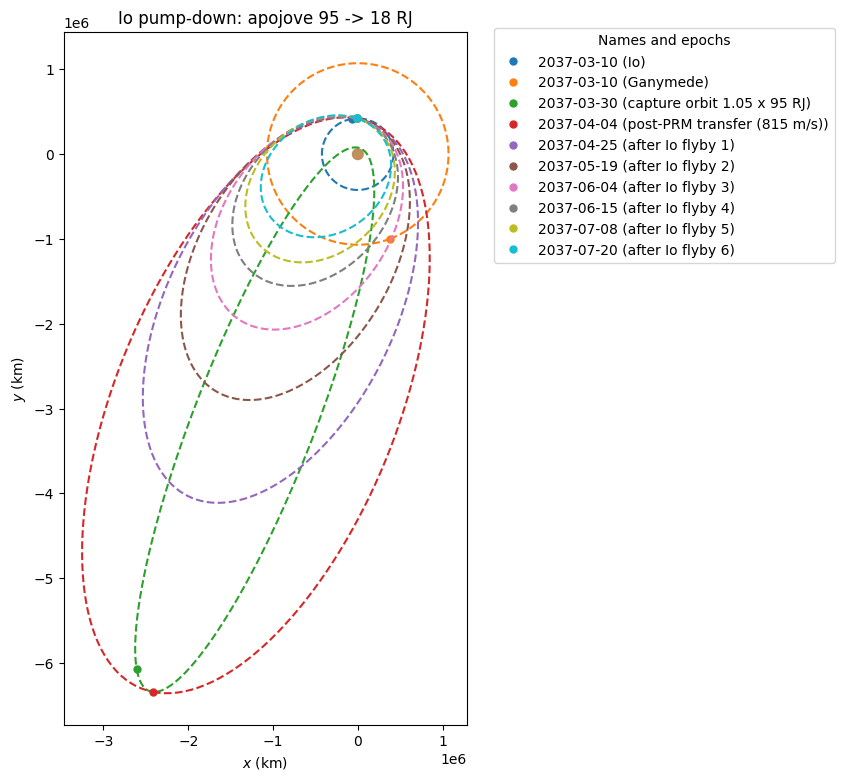

In [10]:
# --- plot 1: the Io pump-down (one burn, six free flybys) --------------------------
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
plotter.plot(moon_orb['Io'], label="Io")
plotter.plot(moon_orb['Ganymede'], label="Ganymede")
plotter.plot(starship_orb, label="capture orbit 1.05 x 95 RJ")
plotter.plot(orb_transfer, label=f"post-PRM transfer ({dv_prm:.0f} m/s)")
for i in range(6):
    plotter.plot(tour_orbits[2 + i], label=f"after Io flyby {i+1}")
plt.title("Io pump-down: apojove 95 -> 18 RJ")
plt.gcf().set_size_inches(9, 9)

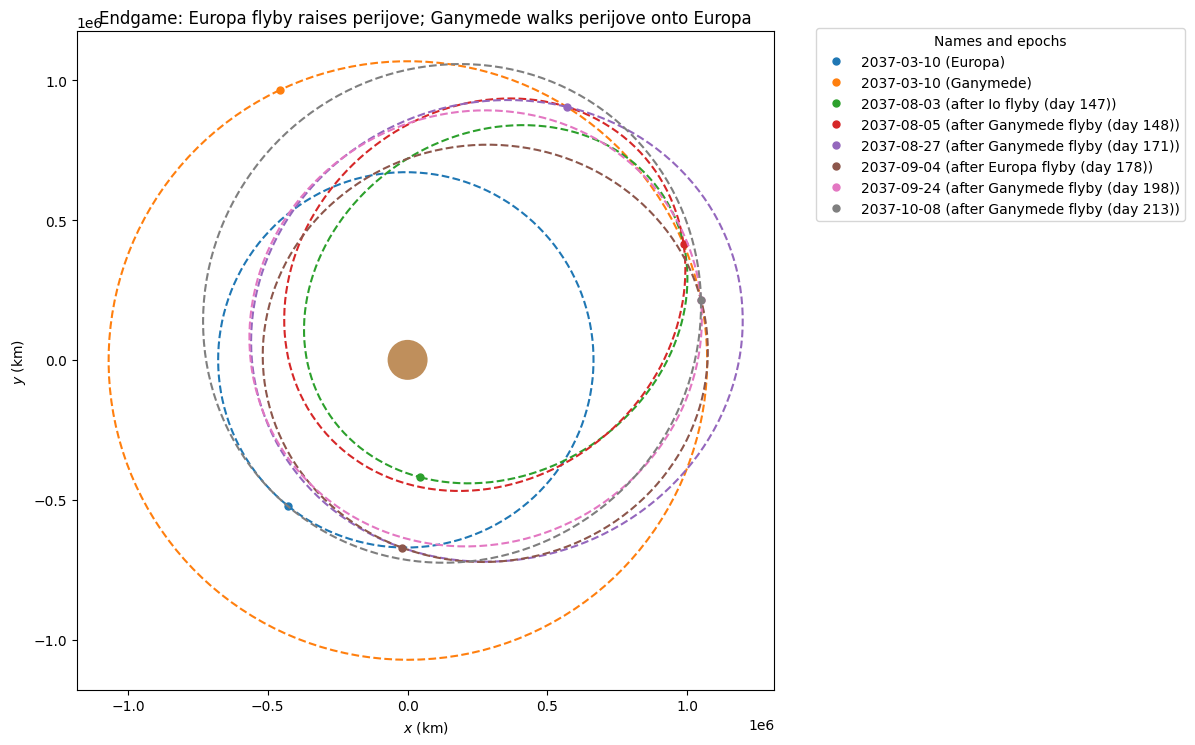

In [11]:
# --- plot 2: the endgame ------------------------------------------------------------
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
plotter.plot(moon_orb['Europa'], label="Europa")
plotter.plot(moon_orb['Ganymede'], label="Ganymede")
for i in range(8, len(tour_orbits)):
    k = i - 2                       # flyby index (0-based) that produced this orbit
    r = rows[k]
    day = rows[k - 1]['t_d'] if k > 0 else 46.0
    plotter.plot(tour_orbits[i], label=f"after {r['at']} flyby (day {day:.0f})")
plt.title("Endgame: Europa flyby raises perijove; Ganymede walks perijove onto Europa")
plt.gcf().set_size_inches(9, 9)

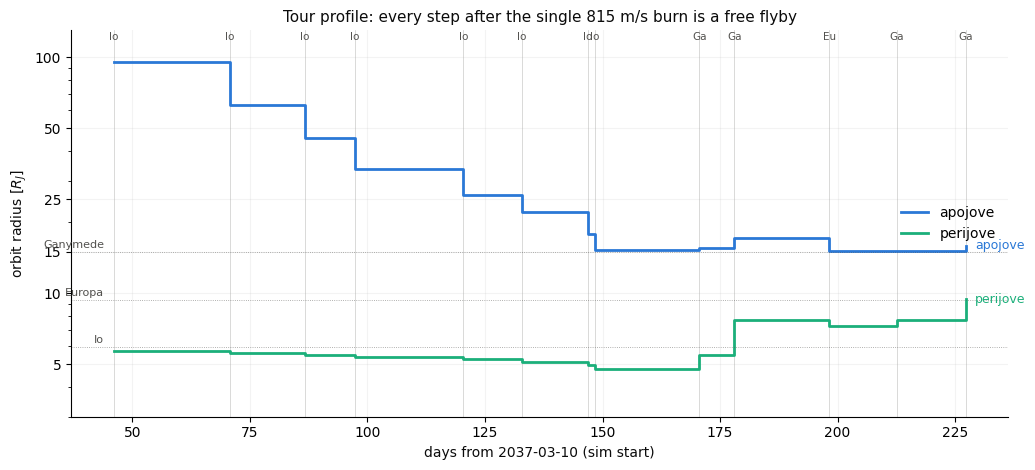

In [12]:
# --- plot 3: tour profile -----------------------------------------------------------
BLUE, AQUA = "#2a78d6", "#1baf7a"
INK, MUT = "#0b0b0b", "#52514e"

ev_d = [46.0] + [r['t_d'] for r in rows]
ev_rp = [orb_transfer.r_p.to(u.km).value / RJ_KM] + [r['rp'] for r in rows]
ev_ra = [orb_transfer.r_a.to(u.km).value / RJ_KM] + [r['ra'] for r in rows]
ev_moon = ['Io'] + [r['at'] for r in rows]

fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.step(ev_d, ev_ra, where='post', color=BLUE, lw=2, label="apojove")
ax.step(ev_d, ev_rp, where='post', color=AQUA, lw=2, label="perijove")
ax.set_yscale('log')
ax.set_ylim(3, 130)
for d, mn in zip(ev_d, ev_moon):
    ax.axvline(d, color=MUT, lw=0.5, alpha=0.3, zorder=0)
    ax.annotate(mn[:2], (d, 118), ha='center', fontsize=7.5, color=MUT)
for name, o in (("Ganymede", moon_orb['Ganymede']), ("Europa", moon_orb['Europa']),
                ("Io", moon_orb['Io'])):
    rj = o.a.to(u.km).value / RJ_KM
    ax.axhline(rj, color=MUT, lw=0.6, ls=':', alpha=0.6)
    ax.annotate(name, (44, rj * 1.04), ha='right', fontsize=8, color=MUT)
ax.annotate("apojove", (ev_d[-1] + 2, ev_ra[-1]), color=BLUE, fontsize=9, va='center')
ax.annotate("perijove", (ev_d[-1] + 2, ev_rp[-1]), color=AQUA, fontsize=9, va='center')
ax.set_yticks([5, 10, 15, 25, 50, 100]); ax.set_yticklabels([5, 10, 15, 25, 50, 100])
ax.set_xlabel("days from 2037-03-10 (sim start)", color=INK)
ax.set_ylabel(r"orbit radius [$R_J$]", color=INK)
ax.set_title("Tour profile: every step after the single 815 m/s burn is a free flyby",
             color=INK, fontsize=11)
ax.legend(frameon=False, loc='center right')
ax.grid(alpha=0.15)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout()

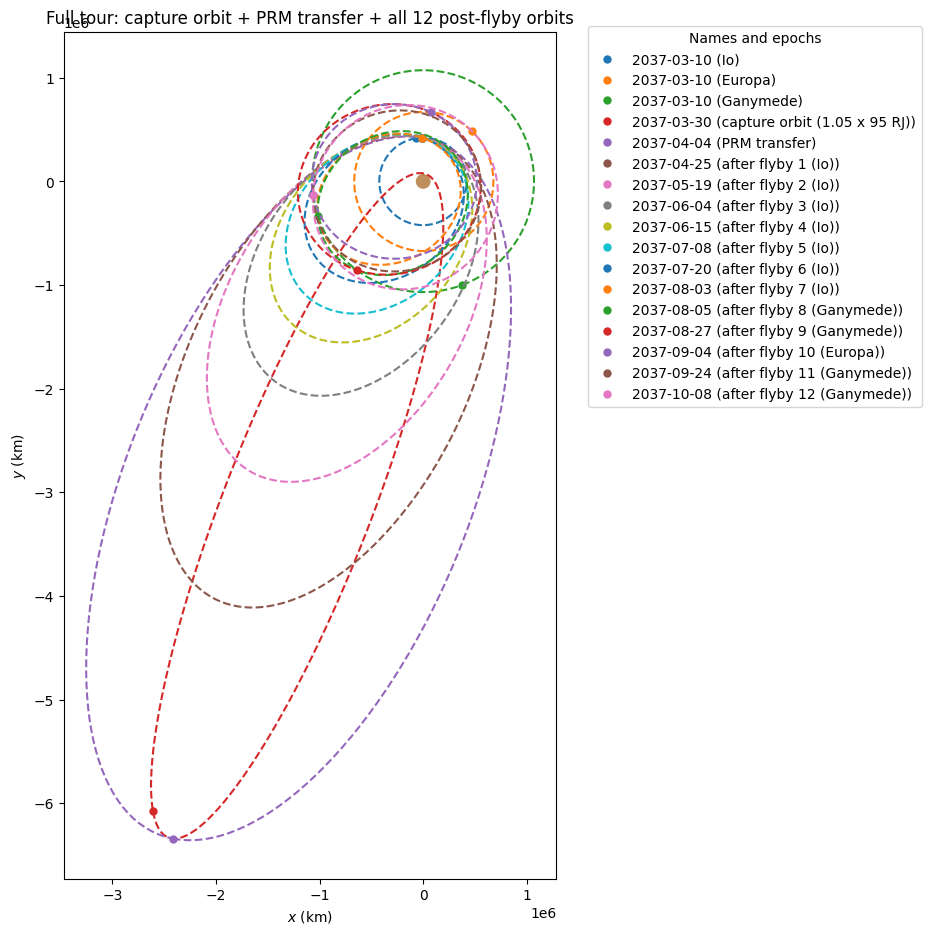

In [13]:
# --- plot 4: the whole tour on one poliastro plot ---------------------------------
# Every heliocentric-analog arc (capture orbit, PRM transfer, and the orbit AFTER each
# of the 12 flybys) drawn together, coloured by which moon's flyby produced it.
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)

# moon reference orbits
plotter.plot(moon_orb['Io'],       label="Io")
plotter.plot(moon_orb['Europa'],   label="Europa")
plotter.plot(moon_orb['Ganymede'], label="Ganymede")

# tour_orbits = [capture, PRM transfer, orbit-after-flyby-1, ..., orbit-after-flyby-12]
plotter.plot(tour_orbits[0], label="capture orbit (1.05 x 95 RJ)")
plotter.plot(tour_orbits[1], label="PRM transfer")
for i in range(2, len(tour_orbits)):
    r = rows[i - 2]                       # the flyby that produced this orbit
    plotter.plot(tour_orbits[i], label=f"after flyby {i-1} ({r['at']})")

plt.title("Full tour: capture orbit + PRM transfer + all 12 post-flyby orbits")
plt.gcf().set_size_inches(11, 11)


### Caveats and comparison

* **Model fidelity == the baseline notebook**: patched conics, instantaneous flybys (rotation of
  $v_\infty$ about the ecliptic normal, re-based at the moon center), coplanar two-body moon motion
  from Horizons osculating states. Encounter *miss* values up to a few thousand km are the phasing
  slop this model tolerates (the baseline's resonant returns show 80–3000 km); real navigation would
  absorb them with m/s-scale TCMs.
* **Why ~8 months, not 7?** 900 m/s buys exactly one perijove-raise burn (no cheaper Lambert phasing
  to a tangential Io encounter exists). Everything else is flybys, and resonant/crossing returns
  quantize the schedule; the search found sub-2 km/s arrivals no earlier than ~day 240 for this
  capture geometry.
* **vs the baseline tour**: ΔV 1545 → **815 m/s**, arrival 2.32 → **1.70 km/s** (EOI to a 50 km
  Europa orbit gets ~400 m/s cheaper as a bonus), 308 → ~227 days (sim-start clock).
* Natural next step: run the pump-down through `libs/jovian_spenvis_model.py` for a dose estimate —
  ~100 days with perijove at 5–5.6 $R_J$ is the radiation price of the free Io assists.

In [14]:
# --- independent verification: is every flyby real, and on the tabulated date? ------
# Everything in `rows` was produced by the fast numpy solvers in cell 3. This cell
# re-derives each encounter from the *poliastro* side instead: take the orbit the
# craft leaves each flyby on, propagate it, and find the closest approach to the moon
# it is supposed to meet. Same two-body moon model as the tour, so a mismatch here is
# a real defect rather than a modelling difference.

from poliastro.twobody.sampling import EpochsArray

TOL_TIME_S  = 60.0     # closest approach must land within a minute of the table
TOL_MISS_KM = 5.0      # and within 5 km of the tabulated miss distance
GRID_MIN    = 10.0     # scan step, minutes
REFINE_N    = 32       # epochs per refinement round
REFINE_R    = 3        # refinement rounds

MU_J = Jupiter.k.to_value(u.km ** 3 / u.s ** 2)

# Sphere of influence: inside this the moon dominates, which is what makes a close
# pass a *flyby* rather than a distant conjunction.
r_soi = {n: moon_orb[n].a.to_value(u.km) * (b.k.to_value(u.km ** 3 / u.s ** 2)
                                            / MU_J) ** 0.4
         for n, b in BODIES.items()}


def _sep_km(orb_sc, moon_name, epochs):
    """|r_spacecraft - r_moon| at each epoch, both propagated with poliastro."""
    r_sc = orb_sc.to_ephem(EpochsArray(epochs)).rv()[0]
    r_mn = moon_orb[moon_name].to_ephem(EpochsArray(epochs)).rv()[0]
    return np.linalg.norm((r_sc - r_mn).to_value(u.km), axis=1)


def closest_approaches(orb_sc, moon_name, t_lo_d, t_hi_d):
    """Interior local minima of the separation, refined. Returns [(day, km), ...].

    Only *interior* minima count: a minimum sitting on a window edge is an artefact of
    where the window was cut, not an encounter.
    """
    n = max(int((t_hi_d - t_lo_d) * 24 * 60 / GRID_MIN) + 1, 8)
    ts = np.linspace(t_lo_d, t_hi_d, n)
    d = _sep_km(orb_sc, moon_name, start_date + ts * u.day)
    out = []
    for i in np.nonzero((d[1:-1] < d[:-2]) & (d[1:-1] < d[2:]))[0] + 1:
        lo, hi = ts[i - 1], ts[i + 1]
        for _ in range(REFINE_R):          # batched bracket shrink, one call per round
            tt = np.linspace(lo, hi, REFINE_N)
            dd = _sep_km(orb_sc, moon_name, start_date + tt * u.day)
            j = int(np.argmin(dd))
            lo, hi = tt[max(j - 1, 0)], tt[min(j + 1, REFINE_N - 1)]
        out.append((0.5 * (lo + hi), float(dd[j])))
    return out


acting_day = [46.0] + [rows[k - 1]['t_d'] for k in range(1, len(rows))]
results = []

for k, r in enumerate(rows):
    orb_out = tour_orbits[2 + k]        # the orbit LEAVING flyby k+1  (see cell 13)
    tg = r['tg']
    fail = []

    # 1. the orbit object really is the one this flyby departed on
    epoch_d = (orb_out.epoch - start_date).to_value(u.day)
    if abs(epoch_d - acting_day[k]) > 1e-6:
        fail.append(f"epoch {epoch_d:.4f} != acting day {acting_day[k]:.4f}")

    # 2. the moon this leg arrives at is the one the next flyby acts at
    if k + 1 < len(rows) and rows[k + 1]['at'] != tg:
        fail.append(f"arrives {tg} but next flyby acts at {rows[k + 1]['at']}")

    # 3. re-derive the encounter from the poliastro orbit
    cas = closest_approaches(orb_out, tg, acting_day[k] + 0.02, r['t_d'] + 1.0)
    if not cas:
        fail.append("no interior closest approach in the window")
        results.append((k, r, None, None, fail, 0, False))
        continue

    t_ca, d_ca = min(cas, key=lambda c: abs(c[0] - r['t_d']))
    dt_s = (t_ca - r['t_d']) * DAY
    dd_km = d_ca - r['miss']

    if abs(dt_s) > TOL_TIME_S:
        fail.append(f"date off by {dt_s:+.1f} s")
    if abs(dd_km) > TOL_MISS_KM:
        fail.append(f"miss off by {dd_km:+.1f} km")
    if d_ca >= r_soi[tg]:
        fail.append(f"{d_ca:.0f} km is outside {tg}'s SOI ({r_soi[tg]:.0f} km)")

    # Is the tabulated encounter the CLOSEST one on offer in this window? (Asking
    # whether it is the *earliest* is useless -- Io laps the craft ~14 times during a
    # 14:1 return, so every lap leaves a local minimum and the answer is always no.)
    closest = abs(d_ca - min(c[1] for c in cas)) < 1e-6
    results.append((k, r, t_ca, d_ca, fail, len(cas), closest))

print("=" * 104)
print("FLYBY VERIFICATION  -- each post-flyby orbit propagated in poliastro to its "
      "own closest approach")
print("=" * 104)
print(f"{'#':>2} {'at':9}->{'tgt':9} {'day (table)':>12} {'dt (s)':>9} "
      f"{'miss (km)':>10} {'d miss':>8} {'/SOI':>6} {'CA':>3}  result")
print("-" * 104)
for k, r, t_ca, d_ca, fail, n_ca, closest in results:
    if t_ca is None:
        print(f"{k+1:>2} {r['at']:9}->{r['tg']:9} {r['t_d']:12.4f} {'--':>9} "
              f"{r['miss']:10.0f} {'--':>8} {'--':>6} {n_ca:>3}  FAIL: {fail[0]}")
        continue
    tag = "PASS" if not fail else "FAIL: " + "; ".join(fail)
    mark = "" if closest else " *"
    print(f"{k+1:>2} {r['at']:9}->{r['tg']:9} {r['t_d']:12.4f} "
          f"{(t_ca - r['t_d']) * DAY:+9.3f} {r['miss']:10.0f} {d_ca - r['miss']:+8.1f} "
          f"{d_ca/r_soi[r['tg']]:6.2f} {n_ca:>3}{mark}  {tag}")

print("-" * 104)
print("dt / d miss = poliastro re-derivation minus the tabulated value.  CA = interior\n"
      "closest approaches in the window; * = the tabulated one is NOT the closest of them")
print("SOI radii:  " + "  ".join(f"{n} {v:.0f} km" for n, v in r_soi.items()))

bad = [k + 1 for k, _, _, _, f, _, _ in results if f]
if bad:
    for k, r, _, _, f, _, _ in results:
        if f:
            print(f"  leg {k+1}: " + "; ".join(f))
    raise AssertionError(f"flyby verification failed on leg(s) {bad}")
print(f"\nALL {len(results)} FLYBYS VERIFIED: each post-flyby orbit reaches its target "
      f"moon within {TOL_TIME_S:.0f} s and {TOL_MISS_KM:.0f} km of the tabulated "
      f"encounter, inside the moon's sphere of influence.")

FLYBY VERIFICATION  -- each post-flyby orbit propagated in poliastro to its own closest approach
 # at       ->tgt        day (table)    dt (s)  miss (km)   d miss   /SOI  CA  result
--------------------------------------------------------------------------------------------------------
 1 Io       ->Io             70.7906    +0.018          0     +0.1   0.00  13  PASS
 2 Io       ->Io             86.7274    -0.067          0     +0.5   0.00   8  PASS
 3 Io       ->Io             97.3520    +0.062          0     +0.5   0.00   5  PASS
 4 Io       ->Io            120.3718    -0.063          0     +0.5   0.00  12  PASS
 5 Io       ->Io            132.7671    -0.042          0     +0.3   0.00   6  PASS
 6 Io       ->Io            146.9332    +0.055          0     +0.4   0.00   8  PASS
 7 Io       ->Ganymede      148.3900    -0.072       4394     +0.0   0.18   1  PASS
 8 Ganymede ->Ganymede      170.5476    -0.009        368     +0.0   0.02   4  PASS
 9 Ganymede ->Europa        178.0004    